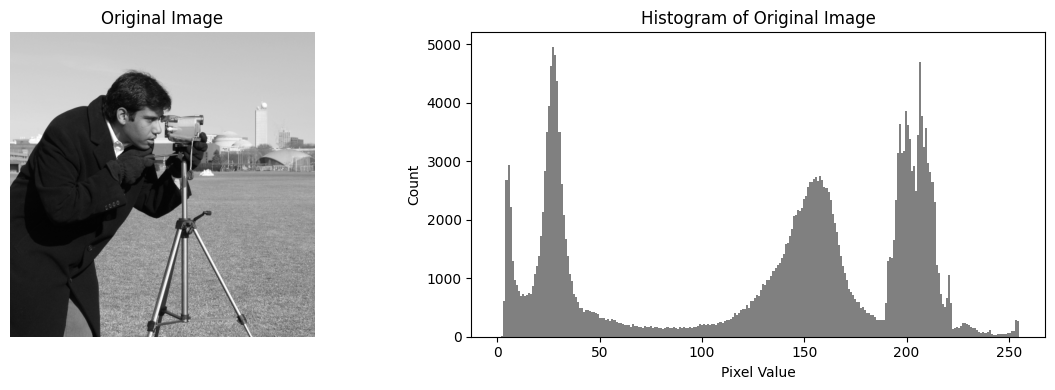

Image shape: (512, 512)
Pixel value range: 0.0 to 255.0


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from skimage import data
from skimage.transform import resize

image = data.camera().astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].hist(image.ravel(), bins=256, color='gray')
axes[1].set_title('Histogram of Original Image')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Pixel value range: {image.min()} to {image.max()}")

In [41]:
def add_gaussian_noise(image, mean=0, std=1):
    print(f"--- Gaussian Noise | mean={mean}, std={std} ---")
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


def add_rayleigh_noise(image, scale=1):
    print(f"--- Rayleigh Noise | scale={scale} ---")
    rayleigh_noise = np.random.rayleigh(scale, image.shape)
    noisy_image = image + rayleigh_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


def add_exponential_noise(image, scale=1):
    print(f"--- Exponential Noise | scale={scale} ---")
    exponential_noise = np.random.exponential(scale, image.shape)
    noisy_image = image + exponential_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    print(f"--- Salt & Pepper Noise | salt={salt_prob}, pepper={pepper_prob} ---")
    noisy_image = image.copy()

    # Salt = white pixels
    num_salt = int(np.ceil(salt_prob * image.size))
    salt_rows = np.random.randint(0, image.shape[0], num_salt)
    salt_cols = np.random.randint(0, image.shape[1], num_salt)
    noisy_image[salt_rows, salt_cols] = 255

    # Pepper = black pixels
    num_pepper = int(np.ceil(pepper_prob * image.size))
    pepper_rows = np.random.randint(0, image.shape[0], num_pepper)
    pepper_cols = np.random.randint(0, image.shape[1], num_pepper)
    noisy_image[pepper_rows, pepper_cols] = 0

    return noisy_image


def add_uniform_noise(image, low=0, high=10):
    print(f"--- Uniform Noise | low={low}, high={high} ---")
    uniform_noise = np.random.uniform(low, high, image.shape)
    noisy_image = image + uniform_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


print("All noise functions defined successfully!")

All noise functions defined successfully!


--- Gaussian Noise | mean=0, std=25 ---
--- Rayleigh Noise | scale=20 ---
--- Exponential Noise | scale=20 ---
--- Salt & Pepper Noise | salt=0.05, pepper=0.05 ---
--- Uniform Noise | low=-30, high=30 ---


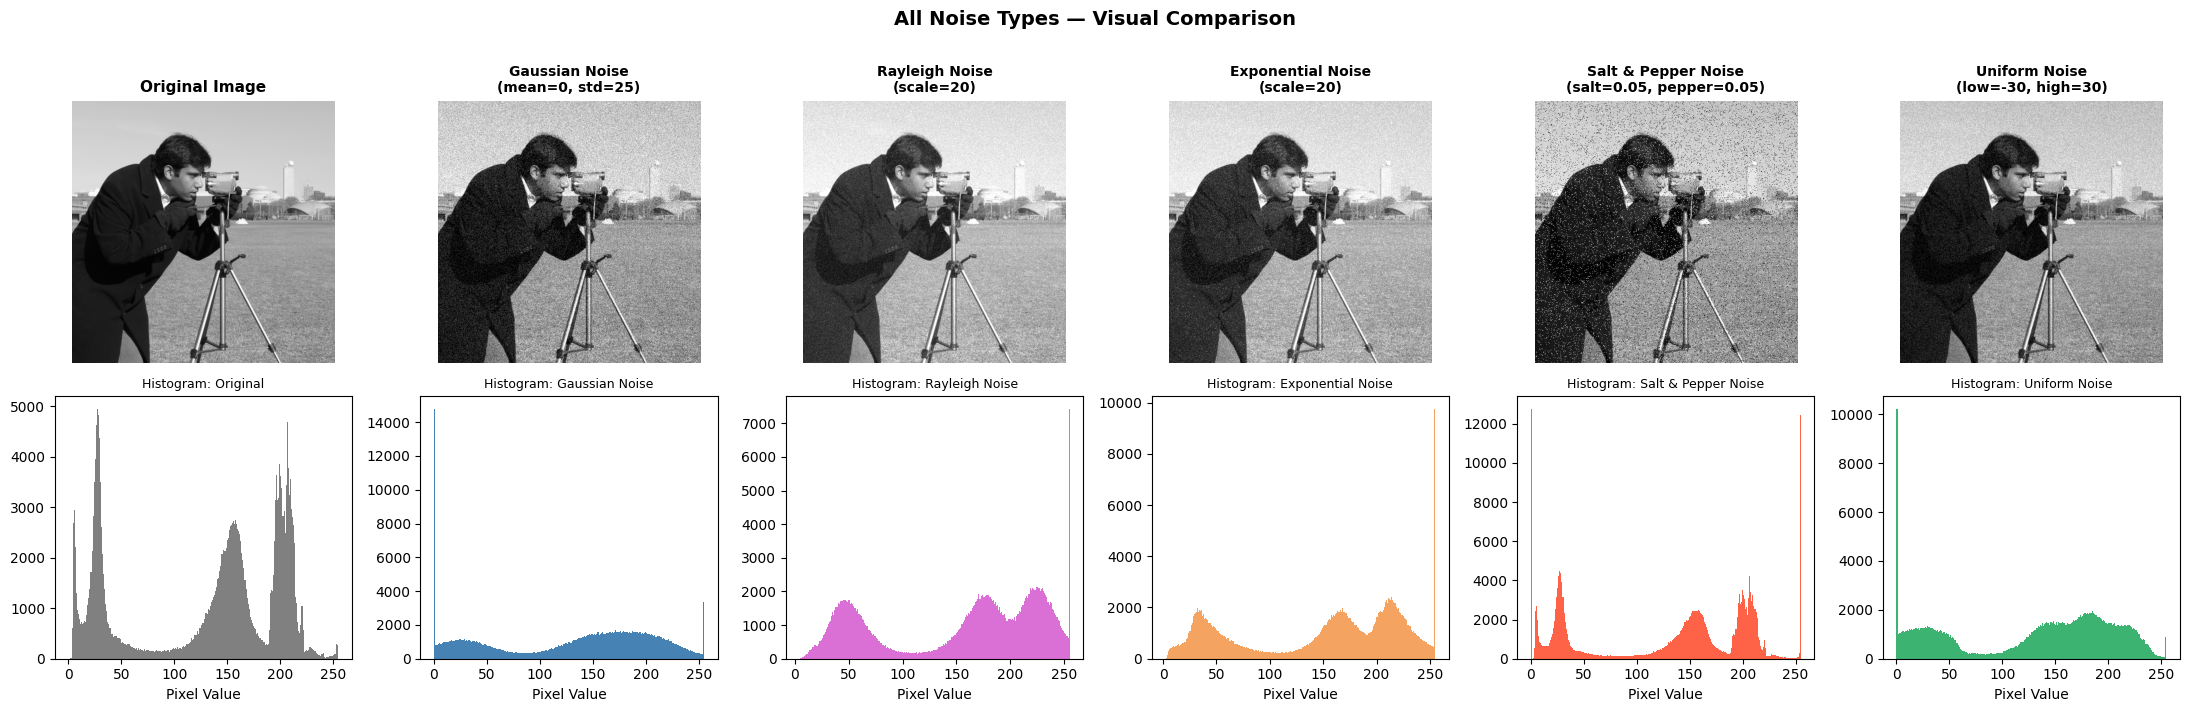

In [42]:

noise_demos = [
    ("Gaussian Noise\n(mean=0, std=25)",      add_gaussian_noise(image, mean=0, std=25)),
    ("Rayleigh Noise\n(scale=20)",             add_rayleigh_noise(image, scale=20)),
    ("Exponential Noise\n(scale=20)",          add_exponential_noise(image, scale=20)),
    ("Salt & Pepper Noise\n(salt=0.05, pepper=0.05)", add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05)),
    ("Uniform Noise\n(low=-30, high=30)",      add_uniform_noise(image, low=-30, high=30)),
]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))


axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i, (title, noisy) in enumerate(noise_demos):
    axes[0, i+1].imshow(noisy, cmap='gray', vmin=0, vmax=255)
    axes[0, i+1].set_title(title, fontsize=10, fontweight='bold')
    axes[0, i+1].axis('off')


axes[1, 0].hist(image.ravel(), bins=256, color='gray')
axes[1, 0].set_title('Histogram: Original', fontsize=9)
axes[1, 0].set_xlabel('Pixel Value')

colors = ['steelblue', 'orchid', 'sandybrown', 'tomato', 'mediumseagreen']
for i, ((title, noisy), color) in enumerate(zip(noise_demos, colors)):
    axes[1, i+1].hist(noisy.ravel(), bins=256, color=color)
    axes[1, i+1].set_title(f'Histogram: {title.split(chr(10))[0]}', fontsize=9)
    axes[1, i+1].set_xlabel('Pixel Value')

plt.suptitle('All Noise Types — Visual Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# STEP 1: Create named noisy image variables
# Each noise type gets its own variable so we can work with them separately
# ============================================================

from skimage.transform import resize

# Use smaller image for speed (filters use loops — slow on large images)
img = resize(image, (128, 128), anti_aliasing=True) * 255
img = img.astype(np.float64)

# --- Named noisy image variables ---
noisy_gaussian  = add_gaussian_noise(img,  mean=0,  std=25)
noisy_rayleigh  = add_rayleigh_noise(img,  scale=20)
noisy_exp       = add_exponential_noise(img, scale=20)
noisy_sp        = add_salt_pepper_noise(img, salt_prob=0.05, pepper_prob=0.05)
noisy_uniform   = add_uniform_noise(img,   low=-30, high=30)

print("\nNoisy image variables created:")
print("  noisy_gaussian  — Gaussian noise  (mean=0, std=25)")
print("  noisy_rayleigh  — Rayleigh noise  (scale=20)")
print("  noisy_exp       — Exponential noise (scale=20)")
print("  noisy_sp        — Salt & Pepper   (salt=5%, pepper=5%)")
print("  noisy_uniform   — Uniform noise   (low=-30, high=30)")

# ============================================================
# STEP 2: Apply matching filters to each noisy image
# ============================================================

print("\nApplying filters (this may take ~30 seconds due to loop-based filters)...")

# Gaussian noise → Mean, Geometric Mean, Midpoint
filt_gauss_mean     = box_filter(noisy_gaussian, 3)
filt_gauss_geo      = geometric_mean_filter(noisy_gaussian, 3)
filt_gauss_midpoint = midpoint_filter(noisy_gaussian, 3)

# Rayleigh noise → Mean, Geometric Mean, Midpoint
filt_rayleigh_mean     = box_filter(noisy_rayleigh, 3)
filt_rayleigh_geo      = geometric_mean_filter(noisy_rayleigh, 3)
filt_rayleigh_midpoint = midpoint_filter(noisy_rayleigh, 3)

# Exponential noise → Geometric Mean, Mean, Midpoint
filt_exp_geo      = geometric_mean_filter(noisy_exp, 3)
filt_exp_mean     = box_filter(noisy_exp, 3)
filt_exp_midpoint = midpoint_filter(noisy_exp, 3)

# Salt & Pepper noise → Median (best!), Alpha-Trimmed, Mean
filt_sp_median = median_filter(noisy_sp, 3)
filt_sp_alpha  = alpha_trimmed_mean_filter(noisy_sp, 3, d=4)
filt_sp_mean   = box_filter(noisy_sp, 3)

# Uniform noise → Mean, Midpoint
filt_uniform_mean     = box_filter(noisy_uniform, 3)
filt_uniform_midpoint = midpoint_filter(noisy_uniform, 3)

print("All filters applied! Scroll down to see comparisons for each noise type.")

--- Gaussian Noise | mean=0, std=25 ---
--- Rayleigh Noise | scale=20 ---
--- Exponential Noise | scale=20 ---
--- Salt & Pepper Noise | salt=0.05, pepper=0.05 ---
--- Uniform Noise | low=-30, high=30 ---

Noisy image variables created:
  noisy_gaussian  — Gaussian noise  (mean=0, std=25)
  noisy_rayleigh  — Rayleigh noise  (scale=20)
  noisy_exp       — Exponential noise (scale=20)
  noisy_sp        — Salt & Pepper   (salt=5%, pepper=5%)
  noisy_uniform   — Uniform noise   (low=-30, high=30)

Applying filters (this may take ~30 seconds due to loop-based filters)...


NameError: name 'box_filter' is not defined

NameError: name 'filt_gauss_mean' is not defined

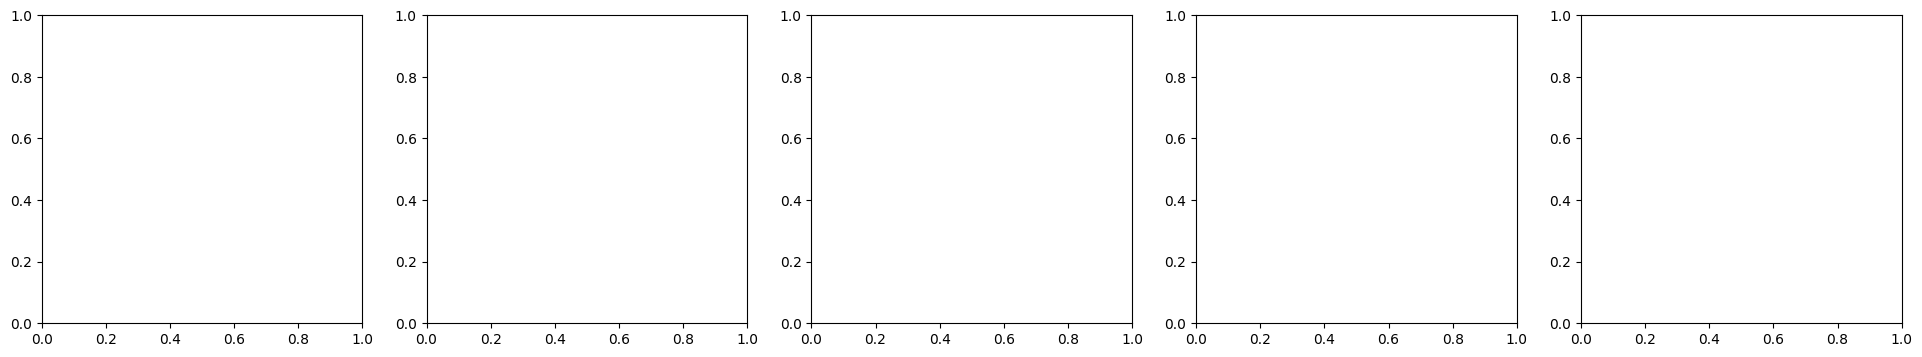

In [28]:
# ============================================================
# FILTER RECOVERY — Gaussian Noise
# Best filters: Mean (box), Geometric Mean, Midpoint
# Gaussian noise = random positive AND negative values → averaging cancels them out
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
imgs   = [image, noisy_gaussian, filt_gauss_mean, filt_gauss_geo, filt_gauss_midpoint]
titles = ['Original', 'Gaussian Noisy\n(mean=0, std=25)',
          'Mean Filter 3x3\n★ BEST for Gaussian',
          'Geometric Mean 3x3\n(slightly less sharp)',
          'Midpoint Filter 3x3\n(decent)']
colors_border = ['black', 'steelblue', 'limegreen', 'gold', 'orange']

for ax, img, title, border in zip(axes, imgs, titles, colors_border):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(border); spine.set_linewidth(3)

plt.suptitle('Gaussian Noise → Best Fix: Mean (Box) Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mean filter is the classic choice for Gaussian noise — it averages out the random variation.")

NameError: name 'filt_rayleigh_mean' is not defined

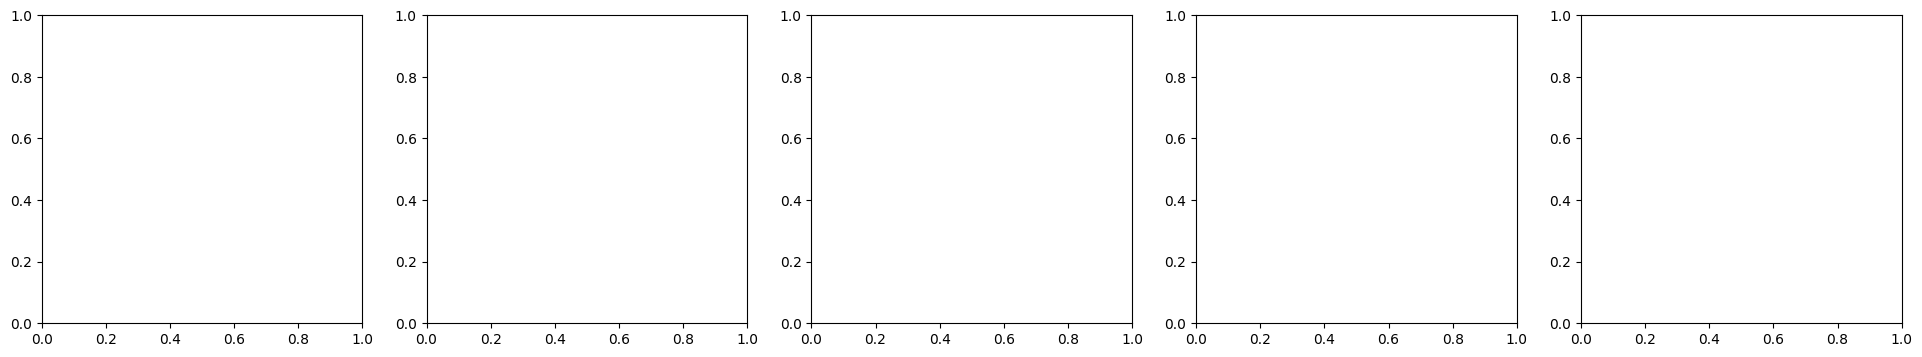

In [29]:
# ============================================================
# FILTER RECOVERY — Rayleigh Noise
# Best filters: Mean (box), Geometric Mean
# Rayleigh noise = always brightens image → averaging pulls values back down
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
imgs   = [image, noisy_rayleigh, filt_rayleigh_mean, filt_rayleigh_geo, filt_rayleigh_midpoint]
titles = ['Original', 'Rayleigh Noisy\n(scale=20)',
          'Mean Filter 3x3\n★ BEST — reduces brightness',
          'Geometric Mean 3x3\n(good)',
          'Midpoint Filter 3x3\n(decent)']
colors_border = ['black', 'orchid', 'limegreen', 'gold', 'orange']

for ax, img, title, border in zip(axes, imgs, titles, colors_border):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(border); spine.set_linewidth(3)

plt.suptitle('Rayleigh Noise → Best Fix: Mean Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mean filter works best for Rayleigh noise — averaging cancels the positive bias.")

NameError: name 'filt_exp_geo' is not defined

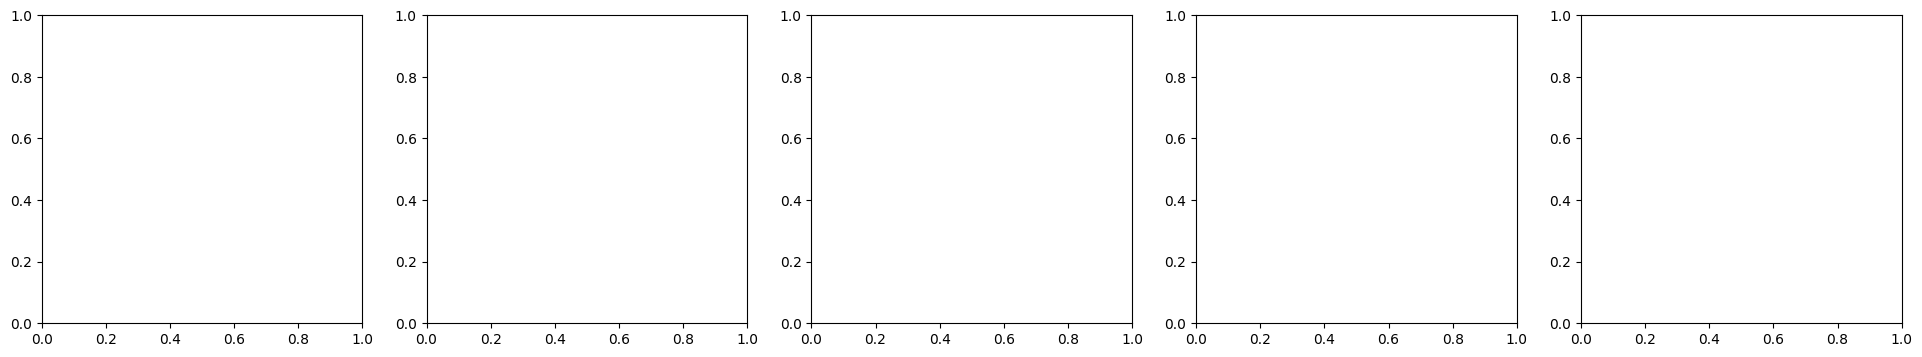

In [30]:
# ============================================================
# FILTER RECOVERY — Exponential Noise
# Best filters: Geometric Mean, Mean (box)
# Exponential noise = always positive, skewed → geo mean handles it well
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
imgs   = [image, noisy_exp, filt_exp_geo, filt_exp_mean, filt_exp_midpoint]
titles = ['Original', 'Exponential Noisy\n(scale=20)',
          'Geometric Mean 3x3\n★ BEST — handles skew',
          'Mean Filter 3x3\n(good)',
          'Midpoint Filter 3x3\n(decent)']
colors_border = ['black', 'sandybrown', 'limegreen', 'gold', 'orange']

for ax, img, title, border in zip(axes, imgs, titles, colors_border):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(border); spine.set_linewidth(3)

plt.suptitle('Exponential Noise → Best Fix: Geometric Mean Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Geometric mean handles exponential noise best due to its skewed distribution.")

NameError: name 'filt_sp_median' is not defined

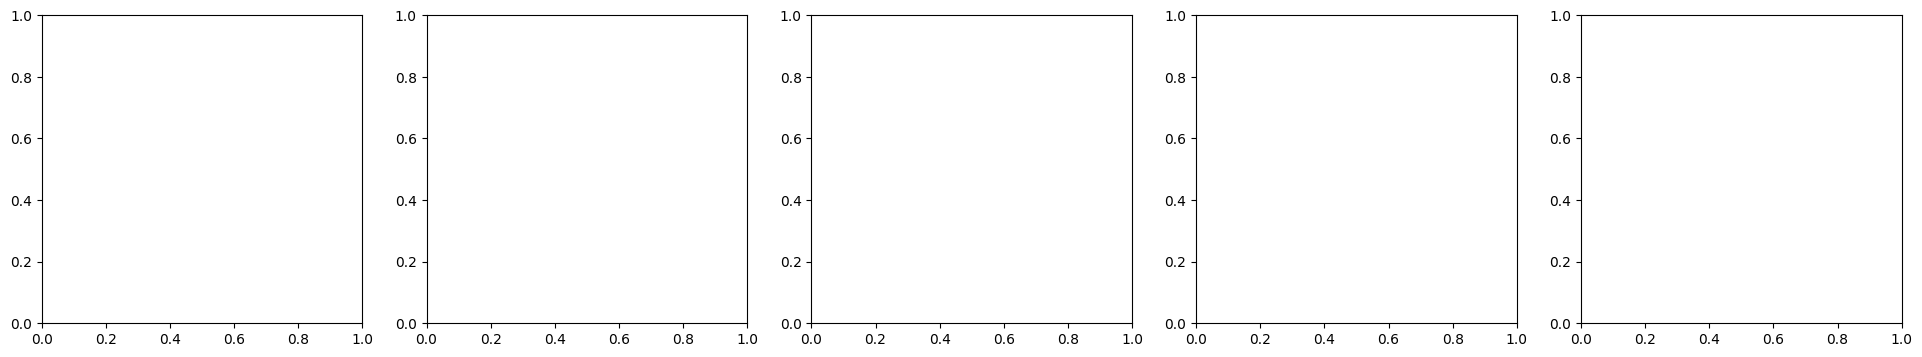

In [31]:
# ============================================================
# FILTER RECOVERY — Salt & Pepper Noise
# Best filter: Median
# S&P noise = random black/white dots → median ignores extremes perfectly
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
imgs   = [image, noisy_sp, filt_sp_median, filt_sp_alpha, filt_sp_mean]
titles = ['Original', 'S&P Noisy\n(5%+5%)',
          'Median Filter 3x3\n★ BEST — removes dots',
          'Alpha-Trimmed d=4\n(decent)',
          'Mean Filter 3x3\n(blurs, not ideal)']
colors_border = ['black', 'tomato', 'limegreen', 'gold', 'salmon']

for ax, img, title, border in zip(axes, imgs, titles, colors_border):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(border); spine.set_linewidth(3)

plt.suptitle('Salt & Pepper Noise → Best Fix: Median Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Median filter is the gold standard for Salt & Pepper noise.")

NameError: name 'filt_uniform_mean' is not defined

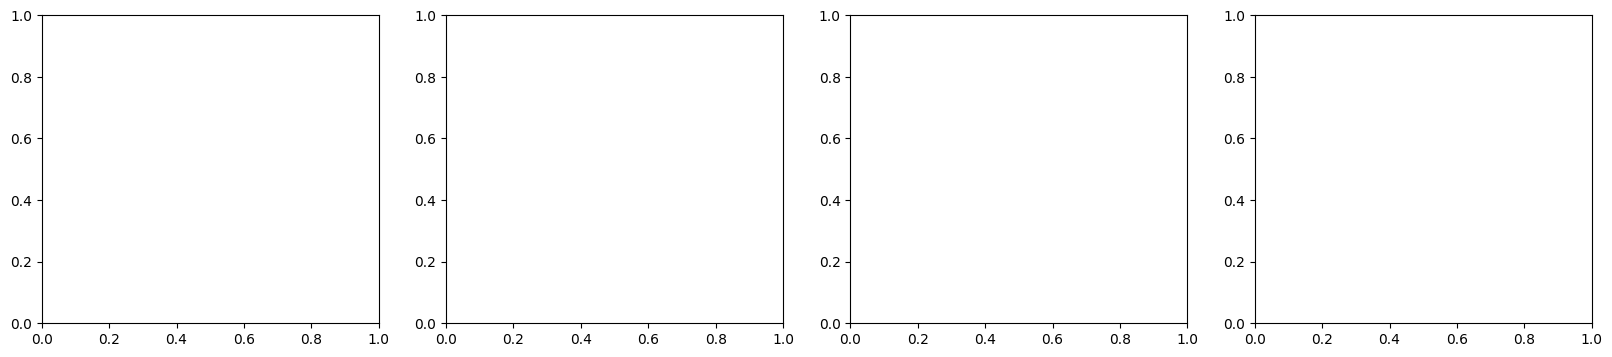

In [ ]:
# ============================================================
# FILTER RECOVERY — Uniform Noise
# Best filters: Mean (box), Midpoint
# Uniform noise = evenly distributed random values → averaging works great
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
imgs   = [image, noisy_uniform, filt_uniform_mean, filt_uniform_midpoint]
titles = ['Original', 'Uniform Noisy', 'Mean Filter 3x3\n(good)', 'Midpoint Filter 3x3\n(good)']
colors_border = ['black', 'mediumseagreen', 'gold', 'orange']

for ax, img, title, border in zip(axes, imgs, titles, colors_border):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values(): 
        spine.set_edgecolor(border); spine.set_linewidth(3)

plt.suptitle('Uniform Noise → Best Fix: Mean Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mean filter and Midpoint filter both work well on uniform noise.")